In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import shap
import warnings
warnings.filterwarnings('ignore')

Chargement

In [2]:
df = pd.read_csv("../data/credit_clean.csv")
print(df.shape)
df.head()

(29965, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


Séparation features / cible

In [3]:
X = df.drop(columns=['default'])
y = df['default']

print(f"Taux de défaut : {y.mean()*100:.1f}%")

Taux de défaut : 22.1%


Train / Test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape}, Test : {X_test.shape}")

Train : (23972, 23), Test : (5993, 23)


Normalisation

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Entraînement des 3 modèles

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])
    results[name] = {"model": model, "y_pred": y_pred, "auc": auc}
    print(f"\n{'='*40}")
    print(f"🔹 {name} — AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))


🔹 Logistic Regression — AUC: 0.7160
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.73      0.25      0.37      1326

    accuracy                           0.81      5993
   macro avg       0.77      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993


🔹 Random Forest — AUC: 0.7580
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4667
           1       0.63      0.36      0.46      1326

    accuracy                           0.81      5993
   macro avg       0.73      0.65      0.67      5993
weighted avg       0.79      0.81      0.79      5993


🔹 XGBoost — AUC: 0.7528
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4667
           1       0.63      0.36      0.46      1326

    accuracy                           0.81      5993
   macro avg       0.74      0.65  

Courbes ROC

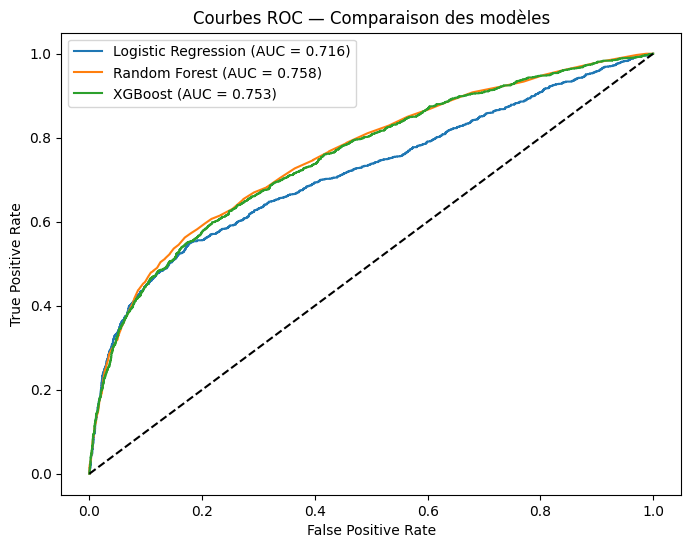

In [7]:
plt.figure(figsize=(8,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['model'].predict_proba(X_test_scaled)[:,1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC — Comparaison des modèles")
plt.legend()
plt.savefig("../visuals/roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()

SHAP

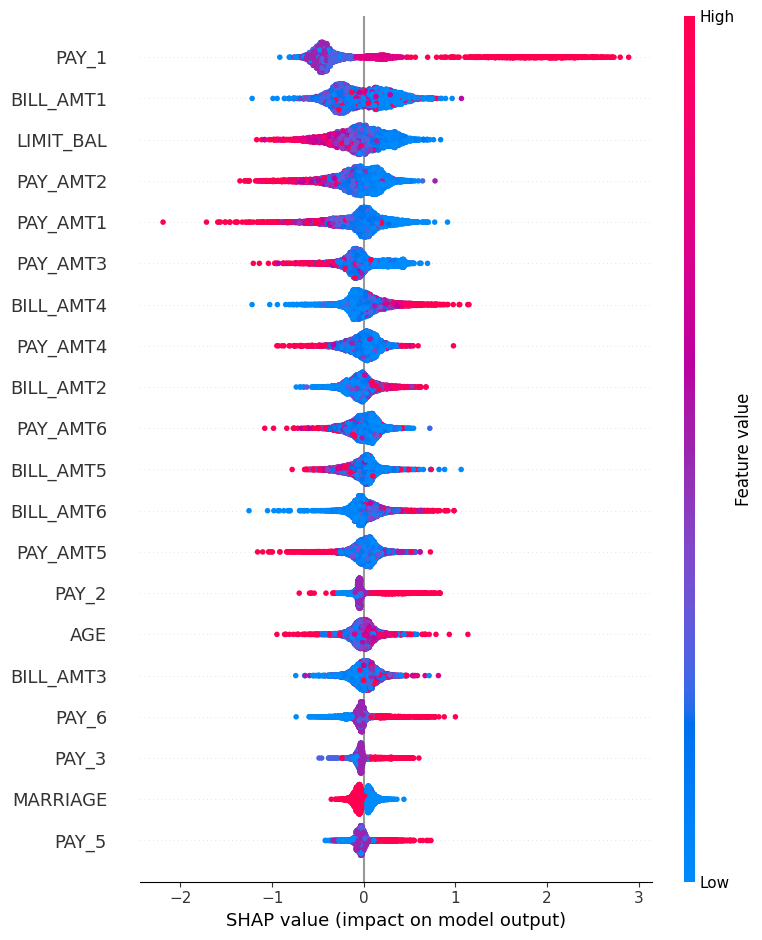

In [8]:
explainer = shap.TreeExplainer(results["XGBoost"]["model"])
shap_values = explainer.shap_values(X_test_scaled)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("../visuals/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

Sauvegarde du meilleur modèle

In [9]:
import pickle

best_model = results["XGBoost"]["model"]
with open("../models/xgb_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Modèle et scaler sauvegardés !")

✅ Modèle et scaler sauvegardés !


Sauvegarde de Random Forest

In [10]:
import pickle

best_model = results["Random Forest"]["model"]
with open("../models/rf_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Random Forest et scaler sauvegardés !")

✅ Random Forest et scaler sauvegardés !


In [11]:
from sklearn.ensemble import RandomForestClassifier
import pickle

rf_fast = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_fast.fit(X_train_scaled, y_train)

# Sauvegarde
with open("../models/rf_model.pkl", "wb") as f:
    pickle.dump(rf_fast, f)

print("✅ Modèle rapide sauvegardé !")

✅ Modèle rapide sauvegardé !
